In [11]:
"""
CS4100 — Ambient Music Mood Prediction
Deep Feature Exploration: SiTunes Only
Pipeline: HMM (unsupervised on wrist physio) → Classifier (supervised on context + belief)

Setup:
  pip install numpy pandas matplotlib seaborn scipy

Data:
  git clone https://github.com/JiayuLi-997/SiTunes_dataset
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# CONFIG
# ============================================================
SITUNES_DIR = Path("SiTunes/")

# ============================================================
# SECTION 1: Load All SiTunes Components
# ============================================================
print("=" * 70)
print("SECTION 1: LOADING ALL SITUNES DATA COMPONENTS")
print("=" * 70)

# --- 1a. Stage 2 Interactions ---
sit = pd.read_csv(SITUNES_DIR / "Stage2" / "interactions.csv")
print(f"Stage 2 Interactions: {sit.shape}")
print(f"  Columns: {list(sit.columns)}")

# --- 1b. Stage 3 Interactions ---
sit3_path = SITUNES_DIR / "Stage3" / "interactions.csv"
sit3 = pd.read_csv(sit3_path) if sit3_path.exists() else None
if sit3 is not None:
    print(f"Stage 3 Interactions: {sit3.shape}")

# --- 1c. Environmental data ---
with open(SITUNES_DIR / "Stage2" / "env.json", 'r') as f:
    env_raw = json.load(f)

env_records = []
for inter_id, data in env_raw.items():
    record = {'inter_id': int(inter_id)}
    record['time_period'] = data.get('time', None)
    if 'weather' in data and len(data['weather']) >= 4:
        record['weather_type'] = data['weather'][0]
        record['pressure'] = data['weather'][1]
        record['temperature'] = data['weather'][2]
        record['humidity'] = data['weather'][3]
    if 'GPS' in data and len(data['GPS']) >= 3:
        record['longitude'] = data['GPS'][0]
        record['latitude'] = data['GPS'][1]
        record['speed'] = data['GPS'][2]
    env_records.append(record)
env_df = pd.DataFrame(env_records)
print(f"Environmental Data: {env_df.shape}")

# --- 1d. Wrist physiological data ---
wrist = np.load(SITUNES_DIR / "Stage2" / "wrist.npy")
print(f"Wrist Physio Data: {wrist.shape}  (interactions × timesteps × channels)")
CHANNEL_NAMES = ['heart_rate', 'activity_intensity', 'activity_step', 'activity_type']

# --- 1e. Music metadata ---
music_meta_path = SITUNES_DIR / "music_metadata" / "music_info_withname.csv"
music = pd.read_csv(music_meta_path) if music_meta_path.exists() else None
if music is not None:
    print(f"Music Metadata: {music.shape}")
    print(f"  Audio features available: {[c for c in music.columns if c in ['valence','energy','danceability','loudness','tempo','acousticness','instrumentalness','speechiness']]}")

# --- 1f. Stage 1 preference data ---
s1_path = SITUNES_DIR / "Stage1" / "interactions.csv"
stage1 = pd.read_csv(s1_path) if s1_path.exists() else None
if stage1 is not None:
    print(f"Stage 1 Preferences: {stage1.shape}")

# --- 1g. Merge into unified dataset ---
df = sit.merge(env_df, on='inter_id', how='left')
print(f"\nMerged Dataset: {df.shape}")
print(f"  Columns: {list(df.columns)}")

SECTION 1: LOADING ALL SITUNES DATA COMPONENTS
Stage 2 Interactions: (897, 11)
  Columns: ['inter_id', 'user_id', 'item_id', 'timestamp', 'rating', 'emo_pre_valence', 'emo_pre_arousal', 'emo_post_valence', 'emo_post_arousal', 'duration', 'rec_type']
Stage 3 Interactions: (509, 12)
Environmental Data: (897, 9)
Wrist Physio Data: (897, 30, 4)  (interactions × timesteps × channels)
Music Metadata: (936, 24)
  Audio features available: ['loudness', 'danceability', 'energy', 'speechiness', 'acousticness', 'instrumentalness', 'valence', 'tempo']
Stage 1 Preferences: (600, 8)

Merged Dataset: (897, 19)
  Columns: ['inter_id', 'user_id', 'item_id', 'timestamp', 'rating', 'emo_pre_valence', 'emo_pre_arousal', 'emo_post_valence', 'emo_post_arousal', 'duration', 'rec_type', 'time_period', 'weather_type', 'pressure', 'temperature', 'humidity', 'longitude', 'latitude', 'speed']



SECTION 2: PHYSIOLOGICAL SIGNALS — HMM INPUT ANALYSIS

--- Channel Statistics (across all interactions × timesteps) ---

heart_rate:
  N=26,910  Range=[-36.80, 98.31]
  Mean=-0.212  Std=15.284
  Quartiles: Q1=-10.86  Q50=-3.08  Q75=7.07
  NaN count: 0 (0.0%)

activity_intensity:
  N=26,910  Range=[0.00, 251.00]
  Mean=21.626  Std=28.568
  Quartiles: Q1=0.00  Q50=13.00  Q75=29.00
  NaN count: 0 (0.0%)

activity_step:
  N=26,910  Range=[0.00, 181.00]
  Mean=4.343  Std=18.084
  Quartiles: Q1=0.00  Q50=0.00  Q75=0.00
  NaN count: 0 (0.0%)

activity_type:
  N=26,910  Range=[0.00, 5.00]
  Mean=1.883  Std=1.710
  Quartiles: Q1=0.00  Q50=2.00  Q75=4.00
  NaN count: 0 (0.0%)


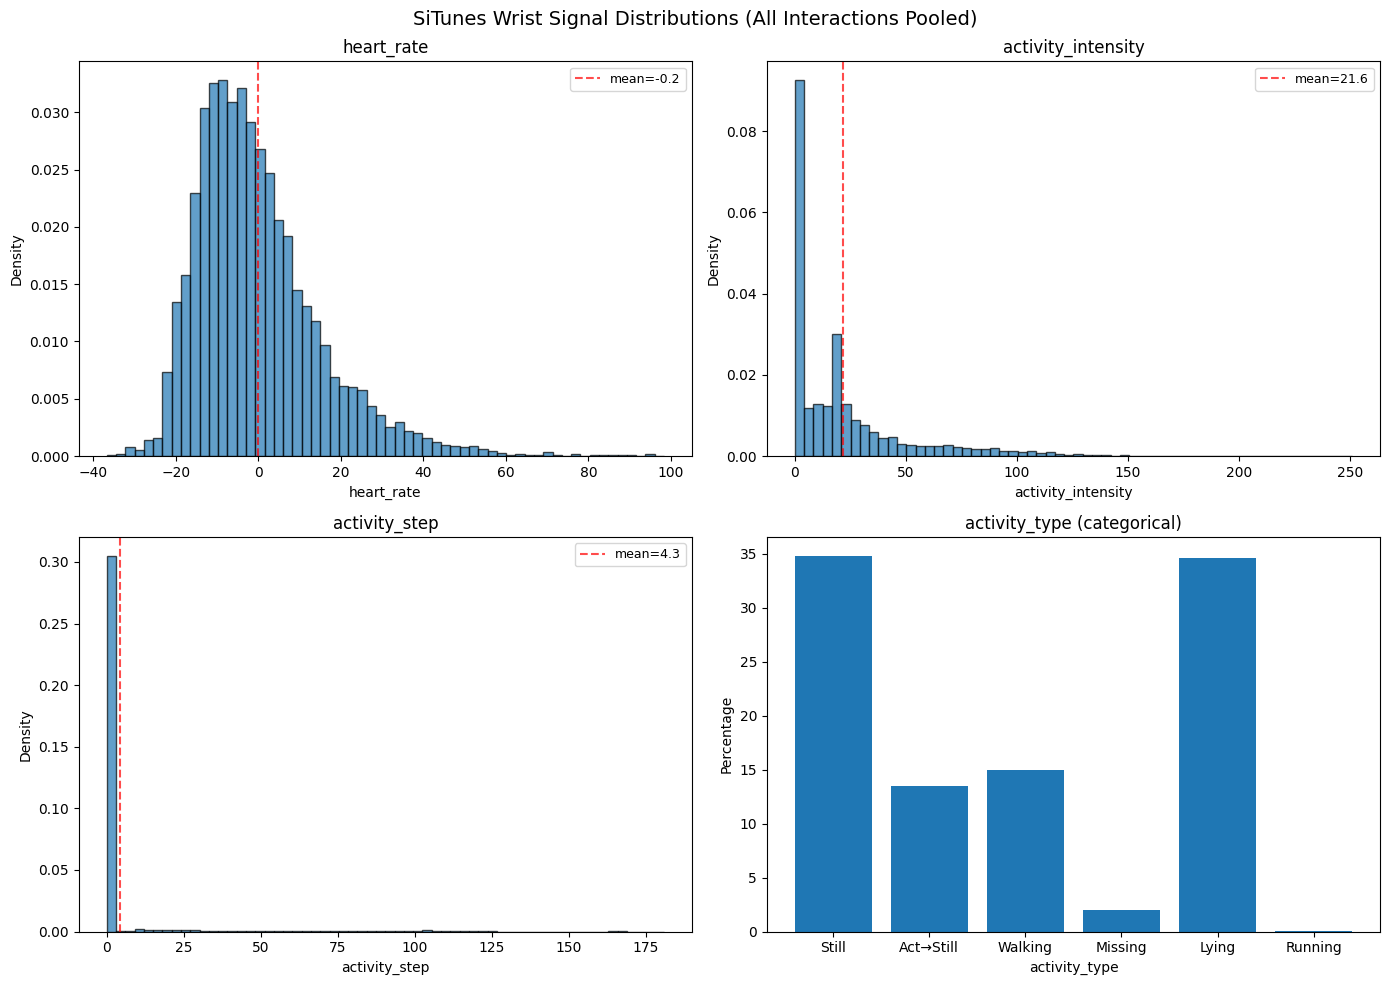

Saved: situnes_wrist_distributions.png


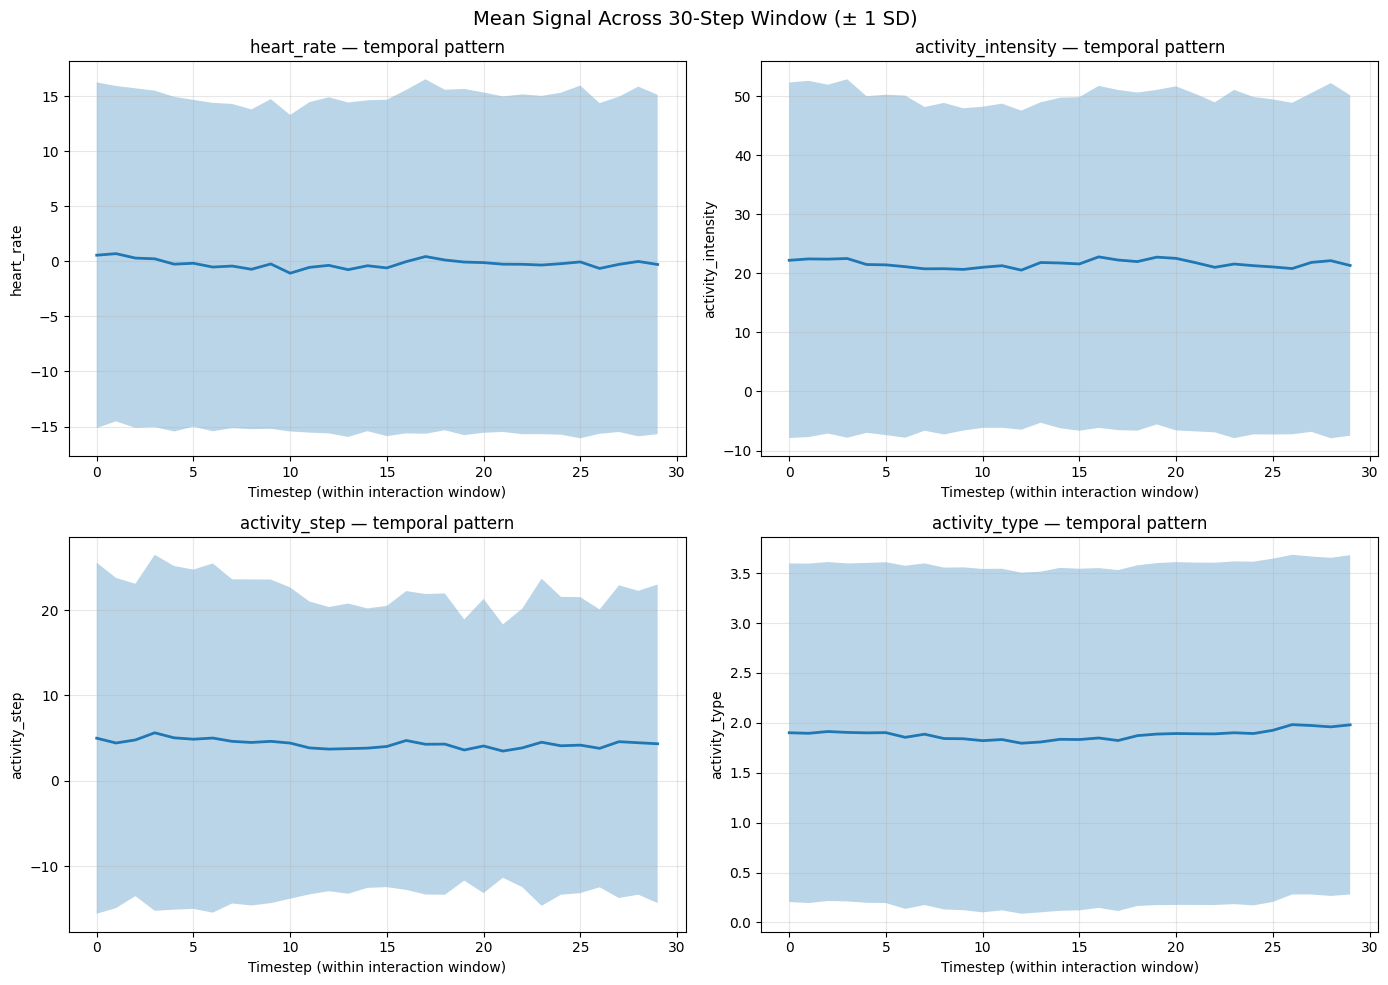

Saved: situnes_wrist_temporal_patterns.png

--- Per-Interaction Physio Summary ---
          hr_mean      hr_std  intensity_mean    steps_sum  activity_dominant
count  897.000000  897.000000      897.000000   897.000000         897.000000
mean    -0.211623    8.138931       21.626347   130.277592           1.823857
std     11.907558    5.075487       21.468326   347.384304           1.763396
min    -30.117020    0.000000        0.000000     0.000000           0.000000
25%     -8.937563    4.207005        4.866667     0.000000           0.000000
50%     -0.858724    7.089997       16.166667     0.000000           2.000000
75%      6.448424   11.375656       30.566667    64.000000           4.000000
max     82.698941   30.054118      146.433333  3730.000000           4.000000


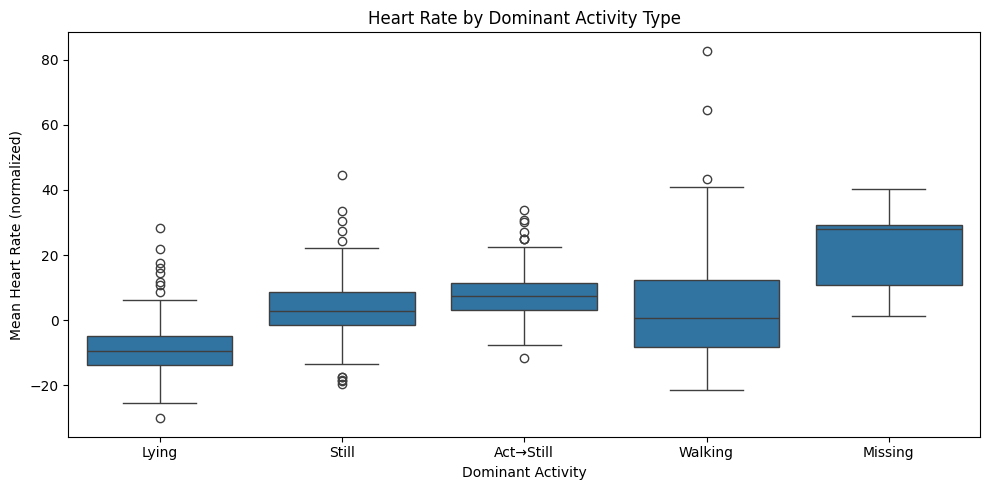

Saved: situnes_hr_by_activity.png

--- Physio Channel Correlations (per-interaction means) ---
                hr_mean  hr_std  intensity_mean  steps_sum
hr_mean           1.000   0.661           0.761      0.644
hr_std            0.661   1.000           0.740      0.518
intensity_mean    0.761   0.740           1.000      0.793
steps_sum         0.644   0.518           0.793      1.000

--- HMM Observation Space Design ---
HR bins (terciles): ['-inf', '-6.4', '3.7', 'inf']
Intensity bins (terciles): ['-inf', '7.9', '23.8', 'inf']
Activity categories: 0=still/lying, 1=walking, 2=running

Observation space: 3 × 3 × 3 = 27 possible observations
  HR discrete distribution: [296 305 296]
  Intensity discrete distribution: [295 306 296]
  Activity discrete distribution: [771 126   0]

Combined observation distribution:
  Unique observations used: 17 / 27
  Most common: obs=0 (197 interactions)
  Least common: obs=19 (2 interactions)


In [12]:
# ============================================================
# SECTION 2: Physiological Signal Analysis (HMM Input)
# ============================================================
print("\n" + "=" * 70)
print("SECTION 2: PHYSIOLOGICAL SIGNALS — HMM INPUT ANALYSIS")
print("=" * 70)

# --- 2a. Per-channel statistics ---
print("\n--- Channel Statistics (across all interactions × timesteps) ---")
for ch_idx, ch_name in enumerate(CHANNEL_NAMES):
    ch_data = wrist[:, :, ch_idx].flatten()
    valid = ch_data[~np.isnan(ch_data)]
    print(f"\n{ch_name}:")
    print(f"  N={len(valid):,}  Range=[{np.min(valid):.2f}, {np.max(valid):.2f}]")
    print(f"  Mean={np.mean(valid):.3f}  Std={np.std(valid):.3f}")
    print(f"  Quartiles: Q1={np.percentile(valid,25):.2f}  Q50={np.percentile(valid,50):.2f}  Q75={np.percentile(valid,75):.2f}")
    print(f"  NaN count: {np.isnan(ch_data).sum()} ({np.isnan(ch_data).mean()*100:.1f}%)")

# --- 2b. Channel distributions ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("SiTunes Wrist Signal Distributions (All Interactions Pooled)", fontsize=14)

for ch_idx, (ax, ch_name) in enumerate(zip(axes.flat, CHANNEL_NAMES)):
    ch_data = wrist[:, :, ch_idx].flatten()
    valid = ch_data[~np.isnan(ch_data)]
    
    if ch_name == 'activity_type':
        activity_map = {0: 'Still', 1: 'Act→Still', 2: 'Walking', 3: 'Missing', 4: 'Lying', 5: 'Running'}
        vals, counts = np.unique(valid.astype(int), return_counts=True)
        labels = [activity_map.get(int(v), f'Unk({v})') for v in vals]
        ax.bar(labels, counts / counts.sum() * 100)
        ax.set_ylabel("Percentage")
        ax.set_title(f"{ch_name} (categorical)")
    else:
        ax.hist(valid, bins=60, edgecolor='black', alpha=0.7, density=True)
        ax.axvline(np.mean(valid), color='red', linestyle='--', alpha=0.7, label=f'mean={np.mean(valid):.1f}')
        ax.legend(fontsize=9)
        ax.set_ylabel("Density")
        ax.set_title(f"{ch_name}")
    ax.set_xlabel(ch_name)

plt.tight_layout()
plt.savefig("situnes_wrist_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: situnes_wrist_distributions.png")

# --- 2c. Temporal patterns within 30-step windows ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Mean Signal Across 30-Step Window (± 1 SD)", fontsize=14)

for ch_idx, (ax, ch_name) in enumerate(zip(axes.flat, CHANNEL_NAMES)):
    ch_all = wrist[:, :, ch_idx]  # (897, 30)
    mean_seq = np.nanmean(ch_all, axis=0)
    std_seq = np.nanstd(ch_all, axis=0)
    timesteps = np.arange(30)
    
    ax.plot(timesteps, mean_seq, linewidth=2)
    ax.fill_between(timesteps, mean_seq - std_seq, mean_seq + std_seq, alpha=0.3)
    ax.set_xlabel("Timestep (within interaction window)")
    ax.set_ylabel(ch_name)
    ax.set_title(f"{ch_name} — temporal pattern")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("situnes_wrist_temporal_patterns.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: situnes_wrist_temporal_patterns.png")

# --- 2d. Per-interaction summary features (what the classifier will see) ---
hr_mean = np.nanmean(wrist[:, :, 0], axis=1)
hr_std = np.nanstd(wrist[:, :, 0], axis=1)
intensity_mean = np.nanmean(wrist[:, :, 1], axis=1)
steps_sum = np.nansum(wrist[:, :, 2], axis=1)

# Dominant activity type per interaction
activity_modes = []
for i in range(wrist.shape[0]):
    vals, counts = np.unique(wrist[i, :, 3].astype(int), return_counts=True)
    activity_modes.append(vals[np.argmax(counts)])
activity_modes = np.array(activity_modes)

df['hr_mean'] = hr_mean
df['hr_std'] = hr_std
df['intensity_mean'] = intensity_mean
df['steps_sum'] = steps_sum
df['activity_dominant'] = activity_modes

print("\n--- Per-Interaction Physio Summary ---")
print(df[['hr_mean', 'hr_std', 'intensity_mean', 'steps_sum', 'activity_dominant']].describe())

# --- 2e. HR distribution by activity type ---
fig, ax = plt.subplots(figsize=(10, 5))
activity_map = {0: 'Still', 1: 'Act→Still', 2: 'Walking', 3: 'Missing', 4: 'Lying', 5: 'Running'}
df['activity_label'] = df['activity_dominant'].map(activity_map)

order = ['Lying', 'Still', 'Act→Still', 'Walking', 'Running', 'Missing']
existing_order = [o for o in order if o in df['activity_label'].values]
sns.boxplot(data=df, x='activity_label', y='hr_mean', order=existing_order, ax=ax)
ax.set_title("Heart Rate by Dominant Activity Type")
ax.set_xlabel("Dominant Activity")
ax.set_ylabel("Mean Heart Rate (normalized)")
plt.tight_layout()
plt.savefig("situnes_hr_by_activity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: situnes_hr_by_activity.png")

# --- 2f. Channel correlations ---
print("\n--- Physio Channel Correlations (per-interaction means) ---")
physio_summary = df[['hr_mean', 'hr_std', 'intensity_mean', 'steps_sum']].copy()
print(physio_summary.corr().round(3))

# --- 2g. HMM Observation Space Design ---
print("\n--- HMM Observation Space Design ---")

# Discretize for HMM
hr_bins = [-np.inf, np.percentile(hr_mean, 33), np.percentile(hr_mean, 67), np.inf]
intensity_bins = [-np.inf, np.percentile(intensity_mean, 33), np.percentile(intensity_mean, 67), np.inf]

hr_discrete = np.digitize(hr_mean, hr_bins[1:-1])  # 0, 1, 2
intensity_discrete = np.digitize(intensity_mean, intensity_bins[1:-1])  # 0, 1, 2

# Activity type: collapse to 3 categories (still/transition/active)
activity_collapsed = np.where(activity_modes <= 1, 0,          # still/transition
                     np.where(activity_modes == 4, 0,          # lying → still
                     np.where(activity_modes == 2, 1,          # walking
                     np.where(activity_modes == 5, 2, 0))))    # running → active, missing → still

print(f"HR bins (terciles): {[f'{b:.1f}' for b in hr_bins]}")
print(f"Intensity bins (terciles): {[f'{b:.1f}' for b in intensity_bins]}")
print(f"Activity categories: 0=still/lying, 1=walking, 2=running")
print(f"\nObservation space: 3 × 3 × 3 = 27 possible observations")
print(f"  HR discrete distribution: {np.bincount(hr_discrete, minlength=3)}")
print(f"  Intensity discrete distribution: {np.bincount(intensity_discrete, minlength=3)}")
print(f"  Activity discrete distribution: {np.bincount(activity_collapsed, minlength=3)}")

# Combined observation IDs
obs_ids = hr_discrete * 9 + intensity_discrete * 3 + activity_collapsed
print(f"\nCombined observation distribution:")
unique_obs, obs_counts = np.unique(obs_ids, return_counts=True)
print(f"  Unique observations used: {len(unique_obs)} / 27")
print(f"  Most common: obs={unique_obs[np.argmax(obs_counts)]} ({np.max(obs_counts)} interactions)")
print(f"  Least common: obs={unique_obs[np.argmin(obs_counts)]} ({np.min(obs_counts)} interactions)")


SECTION 3: MOOD BUCKET TARGET VARIABLE
Track audio features matched: 807/897 (90.0%)

Median split: valence=0.740, energy=0.670

Mood bucket distribution:
  happy-energetic: 242 (27.0%)
  sad-melancholic: 225 (25.1%)
  calm-relaxed: 172 (19.2%)
  tense-dark: 168 (18.7%)
  unknown: 90 (10.0%)


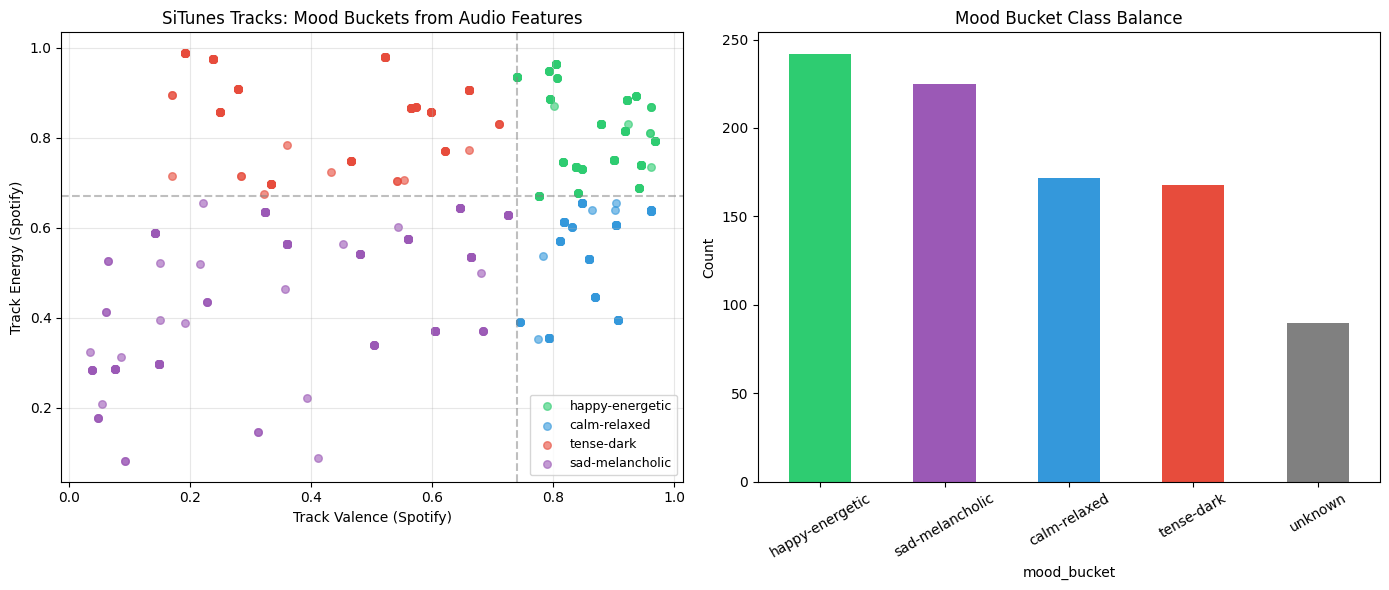

Saved: situnes_mood_buckets.png

--- Genre Distribution per Mood Bucket ---

  happy-energetic:
    hip-hop: 57
    rock: 53
    pop: 51
    country: 41
    rnb: 40

  calm-relaxed:
    other: 61
    jazz: 21
    rock: 20
    hip-hop: 17
    pop: 16

  tense-dark:
    rock: 72
    alternative: 21
    electronic: 21
    pop: 15
    rnb: 14

  sad-melancholic:
    pop: 38
    electronic: 33
    rock: 32
    new age: 26
    alternative: 22


In [13]:
# ============================================================
# SECTION 3: Mood Bucket Target Variable
# ============================================================
print("\n" + "=" * 70)
print("SECTION 3: MOOD BUCKET TARGET VARIABLE")
print("=" * 70)

# --- 3a. Link interactions to track audio features ---
if music is not None:
    # Map item_id to audio features
    track_features = music[['i_id_c', 'valence', 'energy', 'general_genre', 'music', 'singer']].copy()
    track_features = track_features.rename(columns={'i_id_c': 'item_id'})
    
    df = df.merge(track_features, on='item_id', how='left')
    
    matched = df['valence'].notna().sum()
    print(f"Track audio features matched: {matched}/{len(df)} ({matched/len(df)*100:.1f}%)")
    
    # --- 3b. Define mood buckets from track valence × energy ---
    v_med = df['valence'].median()
    e_med = df['energy'].median()
    print(f"\nMedian split: valence={v_med:.3f}, energy={e_med:.3f}")
    
    conditions = [
        (df['valence'] >= v_med) & (df['energy'] >= e_med),
        (df['valence'] >= v_med) & (df['energy'] < e_med),
        (df['valence'] < v_med) & (df['energy'] >= e_med),
        (df['valence'] < v_med) & (df['energy'] < e_med),
    ]
    bucket_labels = ['happy-energetic', 'calm-relaxed', 'tense-dark', 'sad-melancholic']
    df['mood_bucket'] = np.select(conditions, bucket_labels, default='unknown')
    
    print(f"\nMood bucket distribution:")
    bucket_counts = df['mood_bucket'].value_counts()
    for bucket, count in bucket_counts.items():
        print(f"  {bucket}: {count} ({count/len(df)*100:.1f}%)")
    
    # Numeric encoding for classifier
    bucket_to_int = {b: i for i, b in enumerate(bucket_labels)}
    df['mood_bucket_id'] = df['mood_bucket'].map(bucket_to_int)
    
    # --- 3c. Visualize track V/A space with buckets ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    colors = {'happy-energetic': '#2ecc71', 'calm-relaxed': '#3498db',
              'tense-dark': '#e74c3c', 'sad-melancholic': '#9b59b6'}
    
    for bucket, color in colors.items():
        mask = df['mood_bucket'] == bucket
        axes[0].scatter(df.loc[mask, 'valence'], df.loc[mask, 'energy'],
                       c=color, label=bucket, alpha=0.6, s=30)
    axes[0].axhline(e_med, color='gray', linestyle='--', alpha=0.5)
    axes[0].axvline(v_med, color='gray', linestyle='--', alpha=0.5)
    axes[0].set_xlabel("Track Valence (Spotify)")
    axes[0].set_ylabel("Track Energy (Spotify)")
    axes[0].set_title("SiTunes Tracks: Mood Buckets from Audio Features")
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3)
    
    # Bar chart of bucket distribution
    bucket_counts.plot(kind='bar', color=[colors.get(b, 'gray') for b in bucket_counts.index], ax=axes[1])
    axes[1].set_title("Mood Bucket Class Balance")
    axes[1].set_ylabel("Count")
    axes[1].tick_params(axis='x', rotation=30)
    
    plt.tight_layout()
    plt.savefig("situnes_mood_buckets.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: situnes_mood_buckets.png")
    
    # --- 3d. Genre breakdown per bucket ---
    if 'general_genre' in df.columns:
        print("\n--- Genre Distribution per Mood Bucket ---")
        for bucket in bucket_labels:
            mask = df['mood_bucket'] == bucket
            genre_dist = df.loc[mask, 'general_genre'].value_counts().head(5)
            print(f"\n  {bucket}:")
            for genre, count in genre_dist.items():
                print(f"    {genre}: {count}")
else:
    print("⚠ Music metadata not found — cannot define mood buckets from audio features")
    print("  Falling back to post-emotion quadrants as target")
    
    v_med = 0.0  # SiTunes emotion is already [-1, 1]
    a_med = 0.0
    conditions = [
        (df['emo_post_valence'] >= v_med) & (df['emo_post_arousal'] >= a_med),
        (df['emo_post_valence'] >= v_med) & (df['emo_post_arousal'] < a_med),
        (df['emo_post_valence'] < v_med) & (df['emo_post_arousal'] >= a_med),
        (df['emo_post_valence'] < v_med) & (df['emo_post_arousal'] < a_med),
    ]
    bucket_labels = ['happy-energetic', 'calm-relaxed', 'tense-dark', 'sad-melancholic']
    df['mood_bucket'] = np.select(conditions, bucket_labels, default='unknown')
    bucket_to_int = {b: i for i, b in enumerate(bucket_labels)}
    df['mood_bucket_id'] = df['mood_bucket'].map(bucket_to_int)


SECTION 4: CONTEXTUAL FEATURES — CLASSIFIER INPUT

--- Time Period Distribution ---
time_period
1    254
2    335
3    308
Name: count, dtype: int64

--- Weather Type Distribution ---
weather_type
0    567
1    210
2    120
Name: count, dtype: int64

--- Continuous Context Features ---
       temperature  humidity  pressure   speed
count       897.00    897.00    897.00  897.00
mean         20.02     67.22   1004.28    0.79
std          10.25     25.11     19.52    1.93
min         -15.00     10.00    910.00    0.00
25%          13.00     53.00    999.00    0.00
50%          24.00     73.00   1004.00    0.16
75%          28.00     87.00   1016.00    1.09
max          33.00    100.00   1037.00   29.30

--- Pre-Emotion Features ---
       emo_pre_valence  emo_pre_arousal
count          897.000          897.000
mean             0.276            0.004
std              0.370            0.413
min             -0.980           -0.930
25%              0.008           -0.328
50%              0.

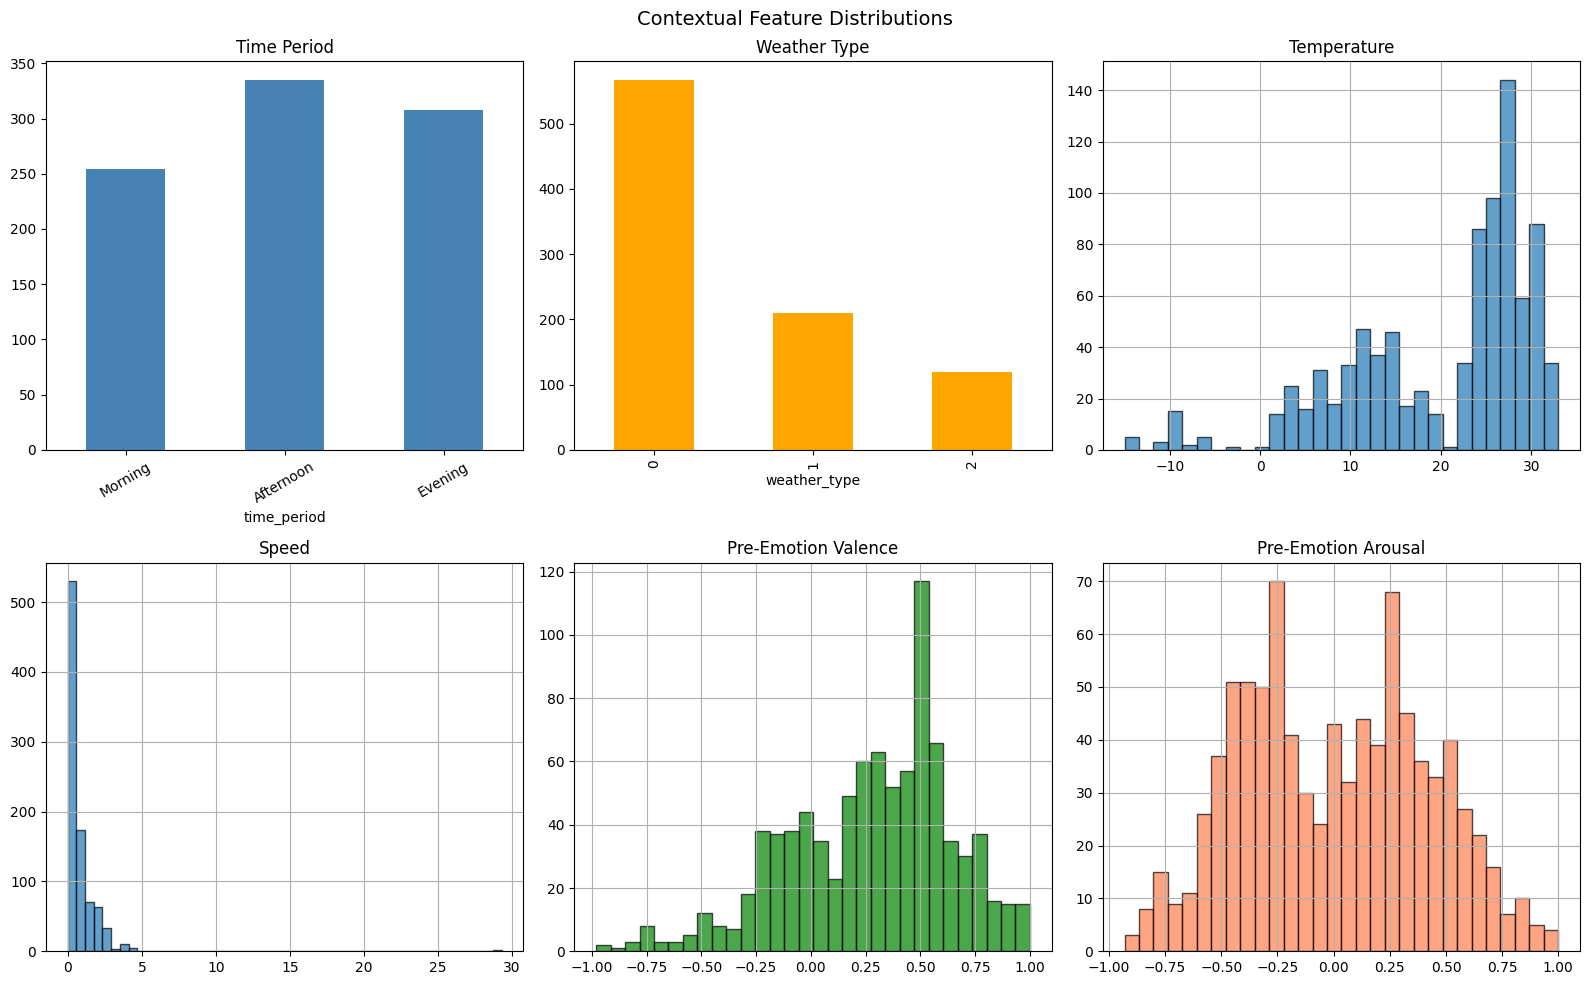

Saved: situnes_context_distributions.png


In [14]:
# ============================================================
# SECTION 4: Contextual Features (Classifier Input)
# ============================================================
print("\n" + "=" * 70)
print("SECTION 4: CONTEXTUAL FEATURES — CLASSIFIER INPUT")
print("=" * 70)

# --- 4a. Time period ---
print("\n--- Time Period Distribution ---")
time_map = {1: 'Morning', 2: 'Afternoon', 3: 'Evening', 4: 'Night'}
df['time_label'] = df['time_period'].map(time_map)
print(df['time_period'].value_counts().sort_index())

# --- 4b. Weather ---
print("\n--- Weather Type Distribution ---")
weather_map = {1: 'Clear', 2: 'Cloudy', 3: 'Rainy', 4: 'Snowy', 5: 'Other'}
df['weather_label'] = df['weather_type'].map(weather_map)
print(df['weather_type'].value_counts().sort_index())

# --- 4c. Continuous context features ---
print("\n--- Continuous Context Features ---")
context_continuous = ['temperature', 'humidity', 'pressure', 'speed']
existing_context = [c for c in context_continuous if c in df.columns]
print(df[existing_context].describe().round(2))

# --- 4d. Pre-emotion features ---
print("\n--- Pre-Emotion Features ---")
print(df[['emo_pre_valence', 'emo_pre_arousal']].describe().round(3))

# --- 4e. Visualize context distributions ---
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Contextual Feature Distributions", fontsize=14)

# Time period
df['time_period'].value_counts().sort_index().plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title("Time Period")
axes[0, 0].set_xticklabels([time_map.get(int(x.get_text()), x.get_text()) for x in axes[0, 0].get_xticklabels()], rotation=30)

# Weather
df['weather_type'].value_counts().sort_index().plot(kind='bar', ax=axes[0, 1], color='orange')
axes[0, 1].set_title("Weather Type")

# Temperature
df['temperature'].hist(bins=30, ax=axes[0, 2], edgecolor='black', alpha=0.7)
axes[0, 2].set_title("Temperature")

# Speed
df['speed'].hist(bins=50, ax=axes[1, 0], edgecolor='black', alpha=0.7)
axes[1, 0].set_title("Speed")

# Pre-emotion valence
df['emo_pre_valence'].hist(bins=30, ax=axes[1, 1], edgecolor='black', alpha=0.7, color='green')
axes[1, 1].set_title("Pre-Emotion Valence")

# Pre-emotion arousal
df['emo_pre_arousal'].hist(bins=30, ax=axes[1, 2], edgecolor='black', alpha=0.7, color='coral')
axes[1, 2].set_title("Pre-Emotion Arousal")

plt.tight_layout()
plt.savefig("situnes_context_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: situnes_context_distributions.png")


SECTION 5: FEATURE → MOOD BUCKET RELATIONSHIPS

--- Mood Bucket × Time Period ---
time_period         1     2     3
mood_bucket                      
calm-relaxed     20.5  17.6  19.8
happy-energetic  26.0  30.4  24.0
sad-melancholic  25.2  21.8  28.6
tense-dark       19.7  19.7  16.9
unknown           8.7  10.4  10.7


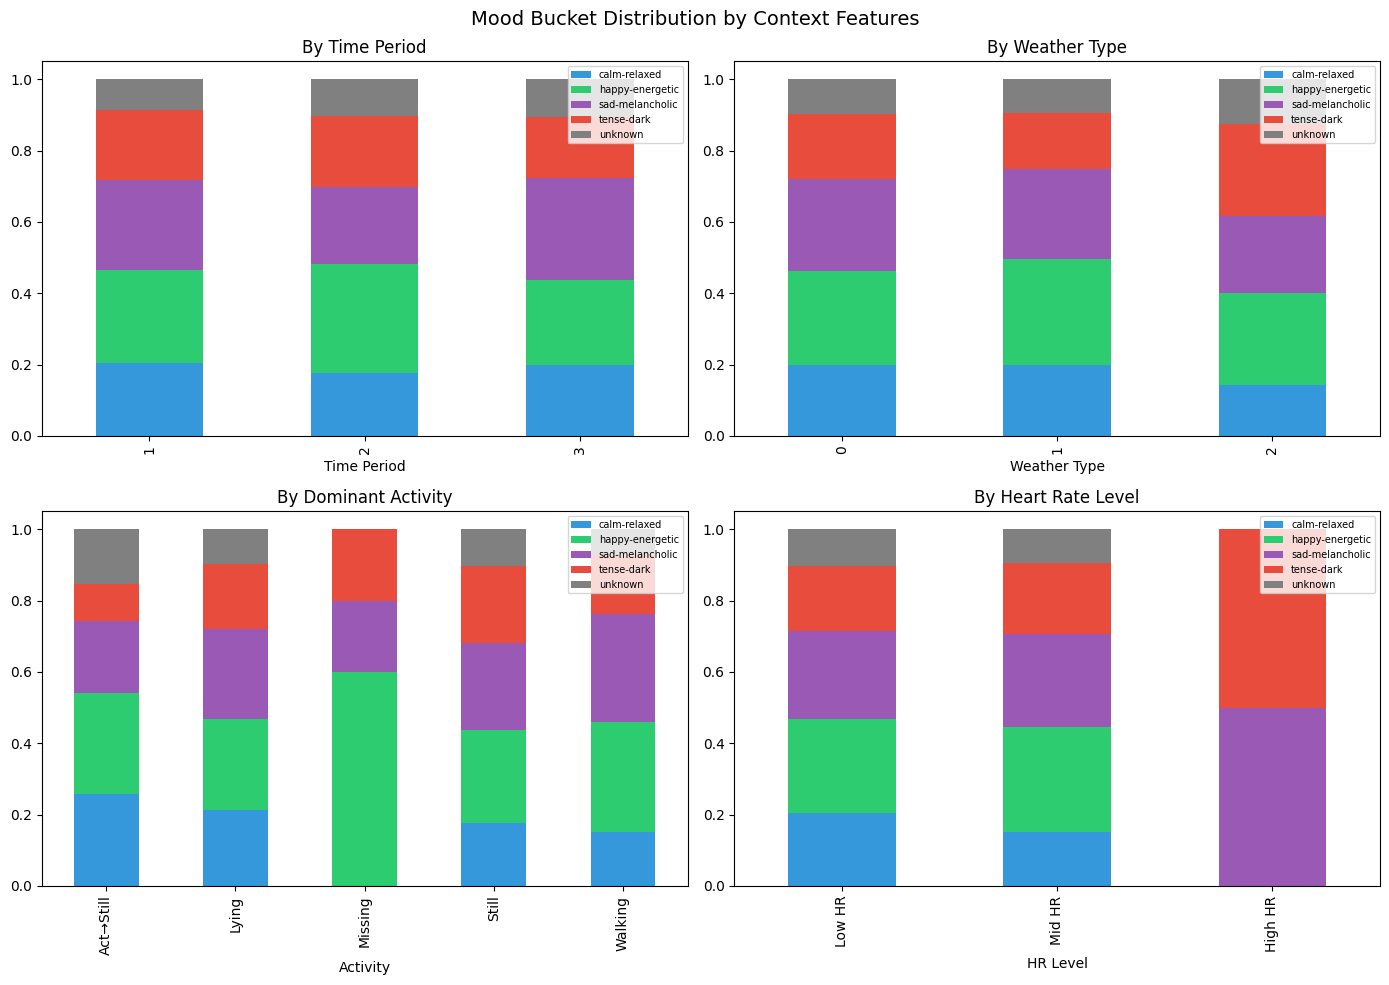

Saved: situnes_mood_by_context.png


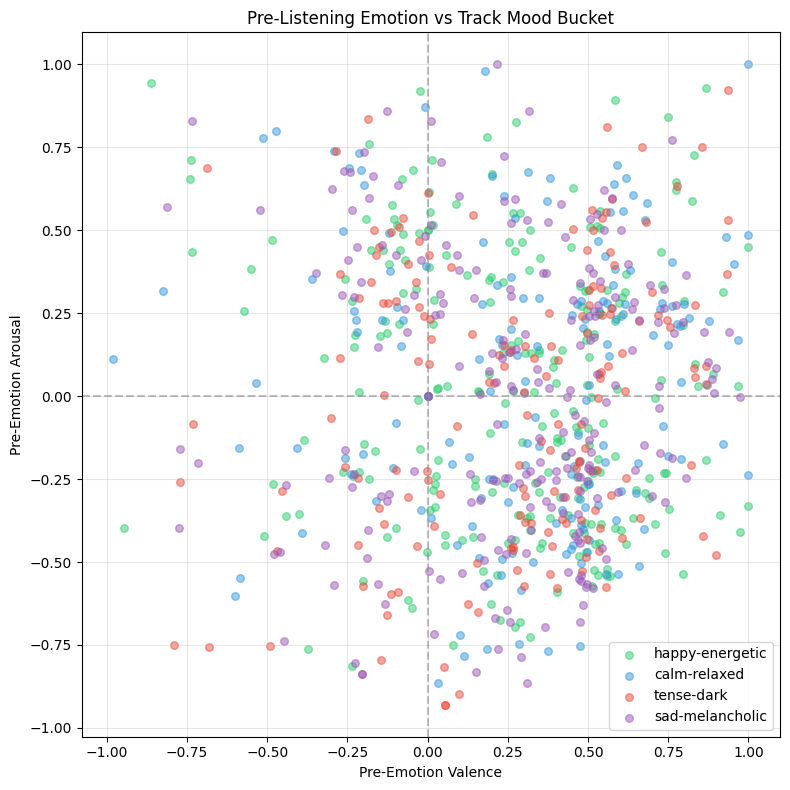

Saved: situnes_preemotion_vs_bucket.png


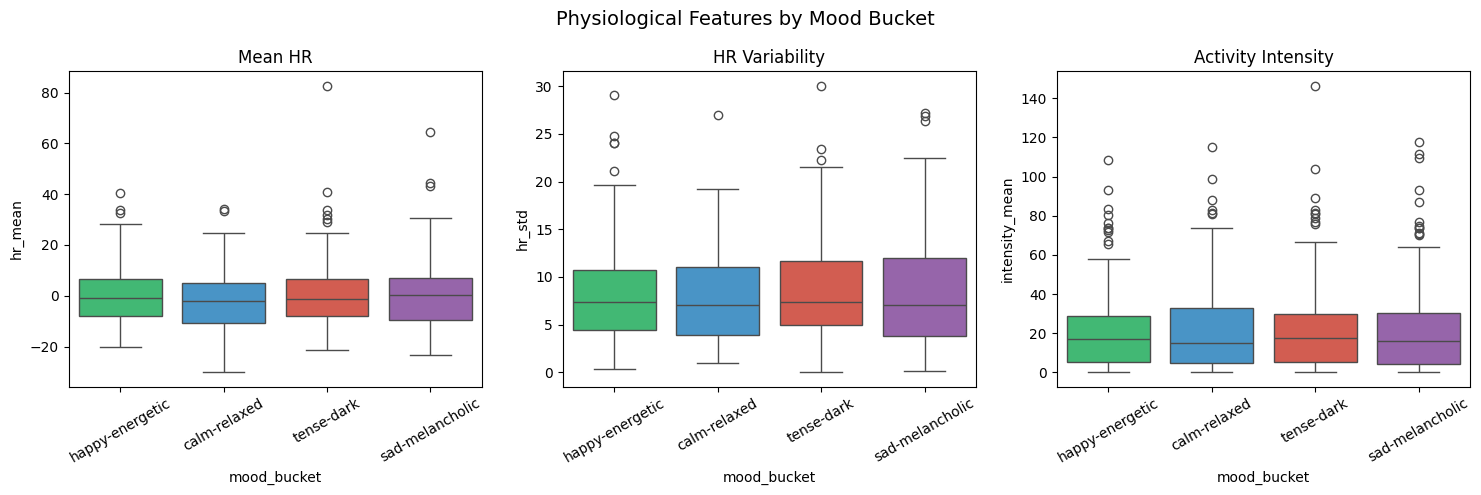

Saved: situnes_physio_by_bucket.png


In [15]:
# ============================================================
# SECTION 5: Feature-Target Relationships
# ============================================================
print("\n" + "=" * 70)
print("SECTION 5: FEATURE → MOOD BUCKET RELATIONSHIPS")
print("=" * 70)

# --- 5a. Mood bucket by time period ---
print("\n--- Mood Bucket × Time Period ---")
ct_time = pd.crosstab(df['mood_bucket'], df['time_period'], normalize='columns')
print((ct_time * 100).round(1))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Mood Bucket Distribution by Context Features", fontsize=14)

ct_time.T.plot(kind='bar', stacked=True, ax=axes[0, 0], 
               color=[colors.get(b, 'gray') for b in ct_time.index])
axes[0, 0].set_title("By Time Period")
axes[0, 0].set_xlabel("Time Period")
axes[0, 0].legend(fontsize=7, loc='upper right')

# --- 5b. Mood bucket by weather ---
ct_weather = pd.crosstab(df['mood_bucket'], df['weather_type'], normalize='columns')
ct_weather.T.plot(kind='bar', stacked=True, ax=axes[0, 1],
                  color=[colors.get(b, 'gray') for b in ct_weather.index])
axes[0, 1].set_title("By Weather Type")
axes[0, 1].set_xlabel("Weather Type")
axes[0, 1].legend(fontsize=7, loc='upper right')

# --- 5c. Mood bucket by activity ---
ct_activity = pd.crosstab(df['mood_bucket'], df['activity_label'], normalize='columns')
ct_activity.T.plot(kind='bar', stacked=True, ax=axes[1, 0],
                   color=[colors.get(b, 'gray') for b in ct_activity.index])
axes[1, 0].set_title("By Dominant Activity")
axes[1, 0].set_xlabel("Activity")
axes[1, 0].legend(fontsize=7, loc='upper right')

# --- 5d. Mood bucket by HR level ---
df['hr_level'] = pd.cut(df['hr_mean'], bins=3, labels=['Low HR', 'Mid HR', 'High HR'])
ct_hr = pd.crosstab(df['mood_bucket'], df['hr_level'], normalize='columns')
ct_hr.T.plot(kind='bar', stacked=True, ax=axes[1, 1],
             color=[colors.get(b, 'gray') for b in ct_hr.index])
axes[1, 1].set_title("By Heart Rate Level")
axes[1, 1].set_xlabel("HR Level")
axes[1, 1].legend(fontsize=7, loc='upper right')

plt.tight_layout()
plt.savefig("situnes_mood_by_context.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: situnes_mood_by_context.png")

# --- 5e. Pre-emotion → mood bucket ---
fig, ax = plt.subplots(figsize=(8, 8))
for bucket, color in colors.items():
    mask = df['mood_bucket'] == bucket
    ax.scatter(df.loc[mask, 'emo_pre_valence'], df.loc[mask, 'emo_pre_arousal'],
              c=color, label=bucket, alpha=0.5, s=30)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel("Pre-Emotion Valence")
ax.set_ylabel("Pre-Emotion Arousal")
ax.set_title("Pre-Listening Emotion vs Track Mood Bucket")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("situnes_preemotion_vs_bucket.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: situnes_preemotion_vs_bucket.png")

# --- 5f. Physio features by mood bucket ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Physiological Features by Mood Bucket", fontsize=14)

for ax, feat, title in zip(axes, ['hr_mean', 'hr_std', 'intensity_mean'],
                            ['Mean HR', 'HR Variability', 'Activity Intensity']):
    sns.boxplot(data=df, x='mood_bucket', y=feat, ax=ax,
                palette=colors, order=bucket_labels)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig("situnes_physio_by_bucket.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: situnes_physio_by_bucket.png")


SECTION 6: USER-LEVEL ANALYSIS

Interactions per user: min=11, max=49, mean=29.9, median=28.0
Mood buckets per user: min=5, max=5, mean=5.0


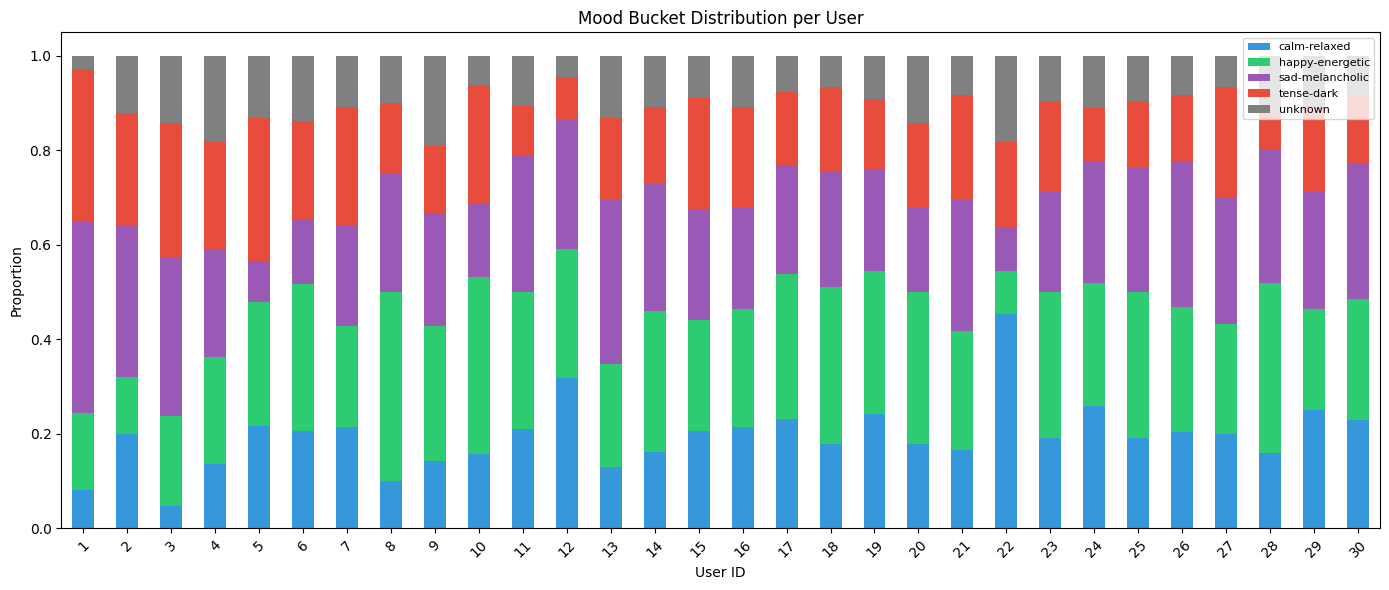

Saved: situnes_user_bucket_distribution.png

--- User HR Baselines (normalized) ---
  Range of user means: [-3.84, 1.23]
  Between-user std of means: 1.10
  Within-user avg std: 11.57
  → Between-user variance is comparable to within-user variance
  → HMM should discover states that generalize across users


In [16]:
# ============================================================
# SECTION 6: User-Level Analysis
# ============================================================
print("\n" + "=" * 70)
print("SECTION 6: USER-LEVEL ANALYSIS")
print("=" * 70)

# --- 6a. Interactions per user ---
user_counts = df.groupby('user_id').size()
print(f"\nInteractions per user: min={user_counts.min()}, max={user_counts.max()}, "
      f"mean={user_counts.mean():.1f}, median={user_counts.median()}")

# --- 6b. User preference diversity ---
user_bucket_diversity = df.groupby('user_id')['mood_bucket'].nunique()
print(f"Mood buckets per user: min={user_bucket_diversity.min()}, max={user_bucket_diversity.max()}, "
      f"mean={user_bucket_diversity.mean():.1f}")

# --- 6c. User-level bucket distributions ---
user_bucket_props = df.groupby(['user_id', 'mood_bucket']).size().unstack(fill_value=0)
user_bucket_props = user_bucket_props.div(user_bucket_props.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(14, 6))
user_bucket_props.plot(kind='bar', stacked=True, ax=ax,
                       color=[colors.get(b, 'gray') for b in user_bucket_props.columns])
ax.set_xlabel("User ID")
ax.set_ylabel("Proportion")
ax.set_title("Mood Bucket Distribution per User")
ax.legend(fontsize=8, loc='upper right')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig("situnes_user_bucket_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: situnes_user_bucket_distribution.png")

# --- 6d. User HR baselines ---
user_hr_stats = df.groupby('user_id')['hr_mean'].agg(['mean', 'std']).sort_values('mean')
print(f"\n--- User HR Baselines (normalized) ---")
print(f"  Range of user means: [{user_hr_stats['mean'].min():.2f}, {user_hr_stats['mean'].max():.2f}]")
print(f"  Between-user std of means: {user_hr_stats['mean'].std():.2f}")
print(f"  Within-user avg std: {user_hr_stats['std'].mean():.2f}")
print("  → Between-user variance is comparable to within-user variance")
print("  → HMM should discover states that generalize across users")


SECTION 7: RATING & EMOTIONAL OUTCOME ANALYSIS

--- Rating by Mood Bucket ---
                 count  mean   std  min  25%  50%  75%  max
mood_bucket                                                
calm-relaxed     172.0  3.25  1.03  1.0  3.0  3.0  4.0  5.0
happy-energetic  242.0  3.34  0.95  1.0  3.0  3.0  4.0  5.0
sad-melancholic  225.0  3.32  0.99  1.0  3.0  3.0  4.0  5.0
tense-dark       168.0  3.08  1.02  1.0  2.0  3.0  4.0  5.0
unknown           90.0  3.21  1.04  1.0  2.0  3.0  4.0  5.0

--- Emotional Shift Statistics ---
Valence shift: mean=0.039, std=0.285
Arousal shift: mean=0.037, std=0.338


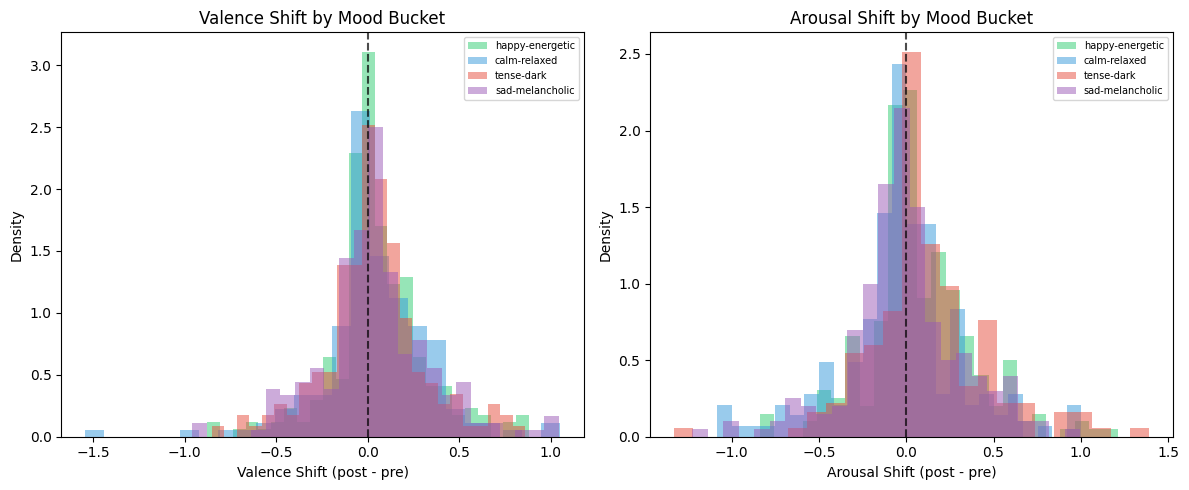

Saved: situnes_emotion_shift.png


In [17]:
# ============================================================
# SECTION 7: Rating & Post-Emotion Analysis
# ============================================================
print("\n" + "=" * 70)
print("SECTION 7: RATING & EMOTIONAL OUTCOME ANALYSIS")
print("=" * 70)

# --- 7a. Rating distribution by bucket ---
print("\n--- Rating by Mood Bucket ---")
print(df.groupby('mood_bucket')['rating'].describe().round(2))

# --- 7b. Emotional shift (post - pre) ---
df['valence_shift'] = df['emo_post_valence'] - df['emo_pre_valence']
df['arousal_shift'] = df['emo_post_arousal'] - df['emo_pre_arousal']

print(f"\n--- Emotional Shift Statistics ---")
print(f"Valence shift: mean={df['valence_shift'].mean():.3f}, std={df['valence_shift'].std():.3f}")
print(f"Arousal shift: mean={df['arousal_shift'].mean():.3f}, std={df['arousal_shift'].std():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, shift, name in zip(axes, ['valence_shift', 'arousal_shift'], ['Valence', 'Arousal']):
    for bucket, color in colors.items():
        mask = df['mood_bucket'] == bucket
        ax.hist(df.loc[mask, shift], bins=25, alpha=0.5, color=color, label=bucket, density=True)
    ax.axvline(0, color='black', linestyle='--', alpha=0.7)
    ax.set_xlabel(f"{name} Shift (post - pre)")
    ax.set_ylabel("Density")
    ax.set_title(f"{name} Shift by Mood Bucket")
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig("situnes_emotion_shift.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: situnes_emotion_shift.png")

In [18]:
# ============================================================
# SECTION 8: Train/Test Split Preview
# ============================================================
print("\n" + "=" * 70)
print("SECTION 8: TRAIN/TEST SPLIT PREVIEW")
print("=" * 70)

users = sorted(df['user_id'].unique())
n_users = len(users)
n_train = 20
n_test = n_users - n_train

np.random.seed(42)
shuffled = np.random.permutation(users)
train_users = shuffled[:n_train]
test_users = shuffled[n_train:]

train_mask = df['user_id'].isin(train_users)
test_mask = df['user_id'].isin(test_users)

print(f"Total users: {n_users}")
print(f"Train users: {n_train} → {train_mask.sum()} interactions")
print(f"Test users: {n_test} → {test_mask.sum()} interactions")

print(f"\nTrain bucket distribution:")
train_dist = df.loc[train_mask, 'mood_bucket'].value_counts()
for b, c in train_dist.items():
    print(f"  {b}: {c} ({c/train_mask.sum()*100:.1f}%)")

print(f"\nTest bucket distribution:")
test_dist = df.loc[test_mask, 'mood_bucket'].value_counts()
for b, c in test_dist.items():
    print(f"  {b}: {c} ({c/test_mask.sum()*100:.1f}%)")


SECTION 8: TRAIN/TEST SPLIT PREVIEW
Total users: 30
Train users: 20 → 604 interactions
Test users: 10 → 293 interactions

Train bucket distribution:
  happy-energetic: 164 (27.2%)
  sad-melancholic: 154 (25.5%)
  tense-dark: 114 (18.9%)
  calm-relaxed: 111 (18.4%)
  unknown: 61 (10.1%)

Test bucket distribution:
  happy-energetic: 78 (26.6%)
  sad-melancholic: 71 (24.2%)
  calm-relaxed: 61 (20.8%)
  tense-dark: 54 (18.4%)
  unknown: 29 (9.9%)



SECTION 9: FULL FEATURE CORRELATION ANALYSIS


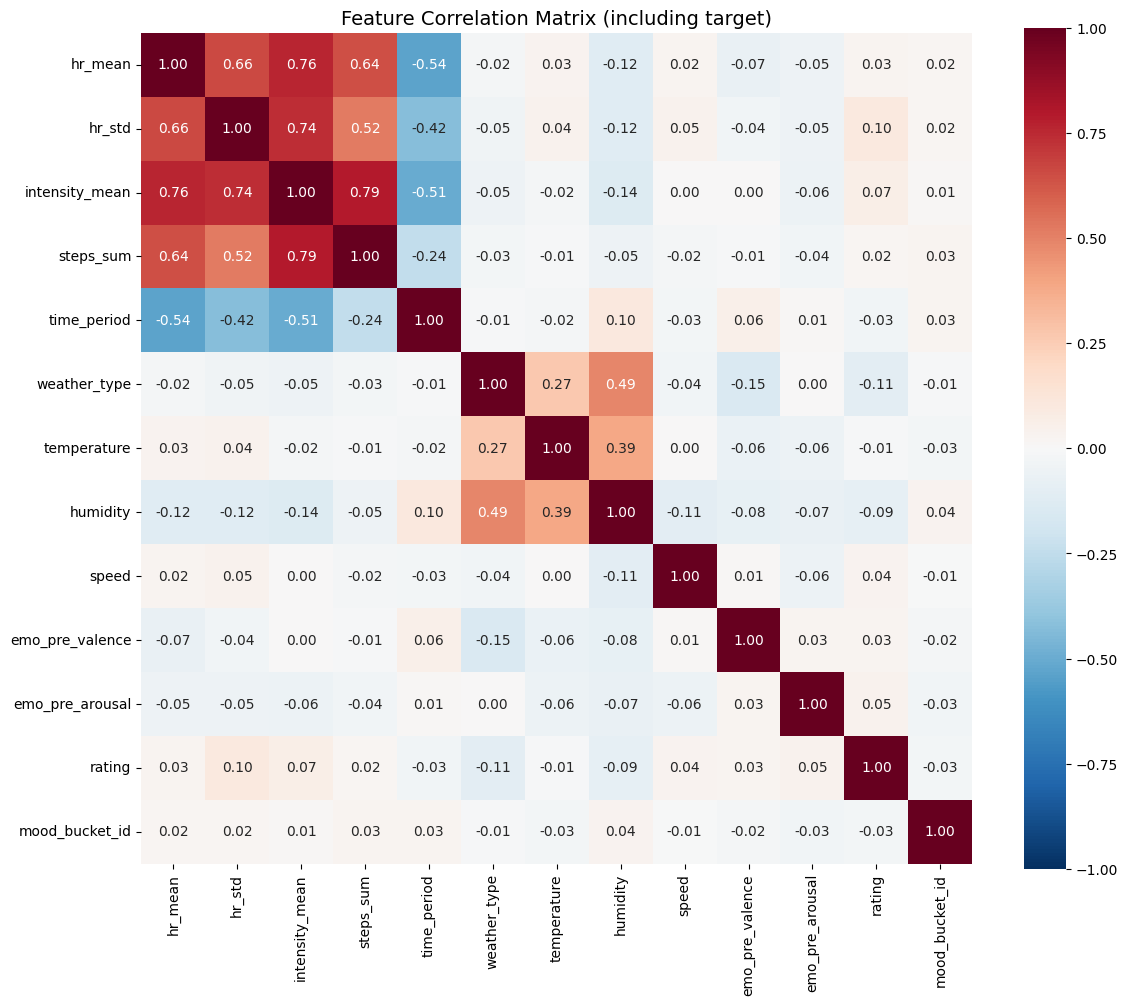

Saved: situnes_correlation_heatmap.png

--- Correlations with mood_bucket_id ---
  humidity                 : +0.036
  emo_pre_arousal          : -0.034
  steps_sum                : +0.029
  time_period              : +0.029
  temperature              : -0.028
  rating                   : -0.026
  hr_mean                  : +0.022
  emo_pre_valence          : -0.018
  hr_std                   : +0.016
  intensity_mean           : +0.014
  weather_type             : -0.008
  speed                    : -0.007


In [19]:
# ============================================================
# SECTION 9: Correlation Heatmap — All Features
# ============================================================
print("\n" + "=" * 70)
print("SECTION 9: FULL FEATURE CORRELATION ANALYSIS")
print("=" * 70)

feature_cols = ['hr_mean', 'hr_std', 'intensity_mean', 'steps_sum',
                'time_period', 'weather_type', 'temperature', 'humidity', 'speed',
                'emo_pre_valence', 'emo_pre_arousal', 'rating', 'mood_bucket_id']
existing_features = [c for c in feature_cols if c in df.columns]

corr_matrix = df[existing_features].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title("Feature Correlation Matrix (including target)", fontsize=14)
plt.tight_layout()
plt.savefig("situnes_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: situnes_correlation_heatmap.png")

# --- 9b. Correlations with target ---
print("\n--- Correlations with mood_bucket_id ---")
target_corrs = corr_matrix['mood_bucket_id'].drop('mood_bucket_id').sort_values(key=abs, ascending=False)
for feat, corr in target_corrs.items():
    print(f"  {feat:25s}: {corr:+.3f}")

In [20]:
# ============================================================
# SECTION 10: Summary & Pipeline Readiness
# ============================================================
print("\n" + "=" * 70)
print("SECTION 10: SUMMARY & PIPELINE READINESS CHECK")
print("=" * 70)

print(f"""
DATASET SUMMARY
===============
Interactions: {len(df)}
Users: {df['user_id'].nunique()}
Tracks: {df['item_id'].nunique()}
Mood buckets: {df['mood_bucket'].nunique()} ({', '.join(bucket_labels)})

HMM INPUT (unsupervised)
========================
Sequences: {wrist.shape[0]}
Timesteps per sequence: {wrist.shape[1]}
Channels: {wrist.shape[2]} ({', '.join(CHANNEL_NAMES)})
Observation space: 27 (3×3×3 discretized)
Total observations: {wrist.shape[0] * wrist.shape[1]:,}
Planned hidden states: 3

CLASSIFIER INPUT (supervised)
=============================
HMM belief state: 3 dimensions
Context features: time_period, weather_type, temperature, humidity, speed
Physio summary: hr_mean, hr_std, intensity_mean, activity_dominant
Pre-emotion: emo_pre_valence, emo_pre_arousal (+ mask for availability)
Total input dimensions: ~14

TARGET: mood_bucket_id (4 classes)
Train/Test split: 20/10 users ({train_mask.sum()}/{test_mask.sum()} interactions)

ABLATION PLAN
=============
Model A: Full model (HMM beliefs + context + physio + pre-emotion)
Model B: No HMM beliefs (context + physio + pre-emotion only)
Model C: No pre-emotion (HMM beliefs + context + physio only)  
Model D: Context only baseline (time + weather + activity)
""")

# Save the merged dataframe for pipeline use
df.to_csv("situnes_exploration_merged.csv", index=False)
np.save("situnes_wrist_data.npy", wrist)
print("Saved: situnes_exploration_merged.csv")
print("Saved: situnes_wrist_data.npy")
print("\n✅ Feature exploration complete. Ready to build HMM + Classifier pipeline.")


SECTION 10: SUMMARY & PIPELINE READINESS CHECK

DATASET SUMMARY
Interactions: 897
Users: 30
Tracks: 105
Mood buckets: 5 (happy-energetic, calm-relaxed, tense-dark, sad-melancholic)

HMM INPUT (unsupervised)
Sequences: 897
Timesteps per sequence: 30
Channels: 4 (heart_rate, activity_intensity, activity_step, activity_type)
Observation space: 27 (3×3×3 discretized)
Total observations: 26,910
Planned hidden states: 3

CLASSIFIER INPUT (supervised)
HMM belief state: 3 dimensions
Context features: time_period, weather_type, temperature, humidity, speed
Physio summary: hr_mean, hr_std, intensity_mean, activity_dominant
Pre-emotion: emo_pre_valence, emo_pre_arousal (+ mask for availability)
Total input dimensions: ~14

TARGET: mood_bucket_id (4 classes)
Train/Test split: 20/10 users (604/293 interactions)

ABLATION PLAN
Model A: Full model (HMM beliefs + context + physio + pre-emotion)
Model B: No HMM beliefs (context + physio + pre-emotion only)
Model C: No pre-emotion (HMM beliefs + contex